**ML1-Notebook6**

***Açelya Yıldırım (Group 17)***

***26.10.2025***

# The ScikitLearn.jl library

The Scikit-learn library is an open-source machine learning library developed for the Python programming language, the first version of which dates back to 2010. It implements many machine learning models, related to classification, regression, clustering or dimensionality reduction. These models include Support Vector Machines (SVM), decision trees, random forests, or k-means. It is currently one of the most widely used libraries in the field of machine learning, due to the large number of functionalities it offers as well as its ease of use, since it provides a uniform interface for training and using models. The documentation for this library is available at https://scikit-learn.org/stable/.

For Julia, the ScikitLearn.jl library implements this interface and the algorithms contained in the scikit-learn library, supporting both Julia's own models and those of the scikit-learn library. The latter is done by means of the PyCall.jl library, which allows code written in Python to be executed from Julia in a transparent way for the user, who only needs to have ScikitLearn.jl installed. Documentation for this library can be found at https://scikitlearnjl.readthedocs.io/en/latest/.

However, recently, some incompatibilities have been reported with some versions of the SSL library. To avoid potential compatibility issues between Julia, PyCall, and ScikitLearn, we will use a different library for this exercise.
The library we will use is MLJ (Machine Learning in Julia), which is not strictly a library but rather a framework that allows the use of various related libraries through a common interface.
As a result, the function names used to create and train models remain the same regardless of the specific models being used.
In the practical sessions of this course, in addition to ANNs, we will use the following models, available within the MLJ framework:

- Support Vector Machines (SVM)
- Decision trees
- kNN

In order to use these models, it is first necessary to install and import the library:

In [4]:
import Pkg;
Pkg.add("MLJ")
using MLJ;

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`


Similarly, it is necessary to install the packages that contain the specific learning algorithms (e.g., LIBSVM, NearestNeighborModels, DecisionTree) as well as the packages that provide the interfaces between these algorithms and the MLJ framework (MLJLIBSVMInterface, MLJDecisionTreeInterface).
To import the models to be used, we can rely on the `MLJ.@load` macro. For example, the following lines import the three models mentioned above, which will be used in this course:

In [6]:
SVMClassifier = MLJ.@load SVC pkg=LIBSVM verbosity=0
kNNClassifier = MLJ.@load KNNClassifier pkg=NearestNeighborModels verbosity=0
DTClassifier = MLJ.@load DecisionTreeClassifier pkg=DecisionTree verbosity=0

MLJDecisionTreeInterface.DecisionTreeClassifier

As can be seen, each model is loaded from a different package. The `verbosity=0` option is simply used to suppress the output message that would otherwise be printed during the import.
This way, we define three functions to create each one of the three models. Each function receives as arguments the specific hyperparameters for the corresponding model.
Below are three examples, one for each type of model that will be used in these course exercises:

In [14]:
import Pkg
Pkg.add("LIBSVM")
Pkg.add("MLJLIBSVMInterface")

using MLJ
using LIBSVM

model = SVMClassifier(kernel=LIBSVM.Kernel.RadialBasis, cost=1.0, gamma=2.0, degree=Int32(3))

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`


SVC(
  kernel = LIBSVM.Kernel.RadialBasis, 
  gamma = 2.0, 
  cost = 1.0, 
  cachesize = 200.0, 
  degree = 3, 
  coef0 = 0.0, 
  tolerance = 0.001, 
  shrinking = true)

In [16]:
using Random

model = DTClassifier(max_depth=4, rng=Random.MersenneTwister(1))

DecisionTreeClassifier(
  max_depth = 4, 
  min_samples_leaf = 1, 
  min_samples_split = 2, 
  min_purity_increase = 0.0, 
  n_subfeatures = 0, 
  post_prune = false, 
  merge_purity_threshold = 1.0, 
  display_depth = 5, 
  feature_importance = :impurity, 
  rng = MersenneTwister(1))

In [18]:
model = kNNClassifier(K=3)

KNNClassifier(
  K = 3, 
  algorithm = :kdtree, 
  metric = Distances.Euclidean(0.0), 
  leafsize = 10, 
  reorder = true, 
  weights = NearestNeighborModels.Uniform())

When creating a kNN model, the main hyperparameter is `K`, which defines the number of neighbors.
For decision trees, the main hyperparameter is `max_depth`, which sets the maximum depth of the tree.
In the case of decision trees, as shown earlier, there is also a parameter called `rng`. This parameter controls the randomness involved in a specific part of the model construction process.

Specifically, for decision trees, this randomness occurs during the selection of features used to split a node. The `DecisionTree` library uses a random number generator (RNG) for this step, which is updated with each call. As a result, different calls to the function (along with subsequent calls to `fit!`) may produce different models, even with the same data.

To control this randomness and make the process deterministic, it is advisable to provide a fixed integer value as the RNG seed, as shown in the previous example.
This ensures that creating a model with a given input-output dataset and a defined set of hyperparameters becomes a reproducible process.

In general, it is preferable to control randomness across the entire model development workflow (e.g., cross-validation, training/test splits) by setting a global random seed at the beginning.
However, for the purposes of these exercises, we will use the `rng` keyword specifically for the decision tree model.

SVMs have a more complex set of hyperparameters, which depend on the kernel function being used.  
First, the hyperparameter `C` controls the trade-off between the margin width and classification error. Lower values allow for more misclassifications (more tolerance), while higher values fit the model more tightly to the data.  
In MLJ, this parameter is passed using the keyword `cost` when calling `SVMClassifier`.

Additionally, it is necessary to specify which kernel to use. This is done using the keyword `kernel`, which can take one of the following values provided by the `LIBSVM` library:

- `LIBSVM.Kernel.Linear`
- `LIBSVM.Kernel.RadialBasis`
- `LIBSVM.Kernel.Sigmoid`
- `LIBSVM.Kernel.Polynomial`

Depending on the kernel selected, different additional hyperparameters are used:

- **Linear kernel**: Only requires `C` (via `cost`).
- **RBF (Radial Basis Function) kernel**: In addition to `C`, it uses `gamma`, which controls the influence of each support vector.
- **Sigmoid kernel**: Uses `C`, `gamma`, and `coef0`. This kernel behaves similarly to a neural network, where `gamma` and `coef0` influence the shape of the decision function.
- **Polynomial kernel**: Uses `C`, `degree` (the degree of the polynomial), `gamma`, and `coef0`.

Typical values for these hyperparameters include:  
`0.001`, `0.1`, `1`, `10`, `100`, `1000`.

The following table summarises the different hyperparameters, the kernels that use them, and typical values they may take.

Note that when calling the `SVMClassifier` function, the hyperparameters use the same names as listed here, except for `C`, which must be passed as `cost`, as shown in the previous example.

It is also important that the arguments passed to the function have the correct type, as required by the `LIBSVM` library. Otherwise, an error may occur.

To prevent this, it is recommended to explicitly cast each hyperparameter to the appropriate type when calling the function.

| Hyperparameter | Applicable Kernels                 | Typical Values                     | Required Type in LIBSVM |
|----------------|------------------------------------|------------------------------------|--------------------------|
| `cost` (`C`)   | Linear, RBF, Sigmoid, Polynomial   | 0.001, 0.1, 1, 10, 100, 1000       | `Float64`               |
| `gamma`        | RBF, Sigmoid, Polynomial           | 0.1, 0.01, 0.001, 0.0001           | `Float64`               |
| `coef0`        | Sigmoid, Polynomial                | 0, 1, 5, 10                        | `Int32`                 |
| `degree`       | Polynomial                         | 2, 3, 4, 5                         | `Float64`               |

Although the basic SVM model is inherently binary, the implementation provided in MLJ already supports multi-class classification.  
Therefore, it is not necessary to manually apply a one-vs-all strategy for multi-class problems.

Once a model has been created, it must be wrapped in a `machine` object. This object acts as a container that associates the model with the data and handles both training and prediction.  
It is a core concept in MLJ and simplifies model workflows by centralizing model fitting (`fit!`) and prediction (`predict`) logic.

A `machine` has three main components:

- **Model**: Specifies the algorithm to be used. It has been created earlier, without any data or learned state.
- **Data**: Provides the input features and target labels (if supervised).
- **Internal State**: Stores learned parameters after the model is trained.

To create a `machine`, you can use the `machine` function, passing in the model, the input features, and the target labels.  
Note that the input data must not be plain arrays. Instead, it should be converted to a supported table format such as `Tables.table`, `DataFrame`, or a `NamedTuple`.  
If your data is currently stored as arrays, as is the case in these exercises, the following line shows how to construct the machine:

In [24]:
#To load the iris data we used in previous notebooks
using Pkg
Pkg.add("RDatasets")

   Resolving package versions...
   Installed Mocking ─── v0.8.1
   Installed RData ───── v0.8.3
   Installed TZJData ─── v1.5.0+2025b
   Installed ExprTools ─ v0.1.10
   Installed TimeZones ─ v1.22.1
   Installed RDatasets ─ v0.7.7
    Updating `~/.julia/environments/v1.10/Project.toml`
  [ce6b1742] + RDatasets v0.7.7
    Updating `~/.julia/environments/v1.10/Manifest.toml`
  [e2ba6199] + ExprTools v0.1.10
  [78c3b35d] + Mocking v0.8.1
⌅ [df47a6cb] + RData v0.8.3
  [ce6b1742] + RDatasets v0.7.7
  [dc5dba14] + TZJData v1.5.0+2025b
  [f269a46b] + TimeZones v1.22.1
        Info Packages marked with ⌅ have new versions available but compatibility constraints restrict them from upgrading. To see why use `status --outdated -m`
Precompiling project...
  ✓ ExprTools
  ✓ TZJData
  ✓ Mocking
  ✓ TimeZones
  ✓ TimeZones → TimeZonesRecipesBaseExt
  ✓ RData
  ✓ RDatasets
  7 dependencies successfully precompiled in 5 seconds. 433 already precompiled.


In [30]:
using Statistics
using RDatasets

# LOAD IRIS DATASET

# Load Iris dataset from RDatasets
iris = dataset("datasets", "iris")

# Separate inputs and targets
inputs = Matrix{Float64}(iris[:, 1:4])  # First 4 columns are features
targets = iris[:, 5]  # Last column is the class

# Display basic info
println("   Iris Dataset loaded.")
println("   Number of samples: ", size(inputs, 1))
println("   Number of features: ", size(inputs, 2))
println("   Classes: ", unique(targets))

# HELPER FUNCTIONS FROM PREVIOUS NOTEBOOKS

# OneHotEncoding function
function oneHotEncoding(feature::AbstractArray{<:Any,1}, classes::AbstractArray{<:Any,1})
    @assert all(in.(feature, Ref(classes))) "All feature values must be in classes"
    
    numClasses = length(classes)
    numPatterns = length(feature)
    
    if numClasses == 2
        return reshape(feature .== classes[2], :, 1)
    end
    
    oneHot = falses(numPatterns, numClasses)
    for i in 1:numClasses
        oneHot[:, i] .= (feature .== classes[i])
    end
    
    return oneHot
end

function oneHotEncoding(feature::AbstractArray{<:Any,1})
    classes = unique(feature)
    return oneHotEncoding(feature, classes)
end

# CONFUSION MATRIX FUNCTIONS

function confusionMatrix(outputs::AbstractArray{Bool,1}, targets::AbstractArray{Bool,1})
    @assert length(outputs) == length(targets)
    
    TP = sum(outputs .& targets)
    TN = sum(.!outputs .& .!targets)
    FP = sum(outputs .& .!targets)
    FN = sum(.!outputs .& targets)
    
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    errorRate = (FP + FN) / (TP + TN + FP + FN)
    
    sensitivity = (TP + FN) == 0 ? ((TN == length(targets)) ? 1.0 : 0.0) : TP / (TP + FN)
    specificity = (TN + FP) == 0 ? ((TP == length(targets)) ? 1.0 : 0.0) : TN / (TN + FP)
    PPV = (TP + FP) == 0 ? ((TN == length(targets)) ? 1.0 : 0.0) : TP / (TP + FP)
    NPV = (TN + FN) == 0 ? ((TP == length(targets)) ? 1.0 : 0.0) : TN / (TN + FN)
    
    F1 = (sensitivity == 0.0 && PPV == 0.0) ? 0.0 : 2 * (PPV * sensitivity) / (PPV + sensitivity)
    
    confMatrix = [TN FP; FN TP]
    
    return accuracy, errorRate, sensitivity, specificity, PPV, NPV, F1, confMatrix
end

function confusionMatrix(outputs::AbstractArray{<:Real,1}, targets::AbstractArray{Bool,1}; threshold::Real=0.5)
    return confusionMatrix(outputs .>= threshold, targets)
end

function confusionMatrix(outputs::AbstractArray{<:Any,1}, targets::AbstractArray{<:Any,1}, classes::AbstractArray{<:Any,1})
    @assert length(outputs) == length(targets)
    @assert all(in.(outputs, Ref(classes)))
    @assert all(in.(targets, Ref(classes)))
    
    numClasses = length(classes)
    confMatrix = zeros(Int, numClasses, numClasses)
    
    for i in 1:length(outputs)
        outputIdx = findfirst(isequal(outputs[i]), classes)
        targetIdx = findfirst(isequal(targets[i]), classes)
        confMatrix[outputIdx, targetIdx] += 1
    end
    
    sensitivity = zeros(numClasses)
    specificity = zeros(numClasses)
    PPV = zeros(numClasses)
    NPV = zeros(numClasses)
    F1 = zeros(numClasses)
    
    for i in 1:numClasses
        TP = confMatrix[i, i]
        FN = sum(confMatrix[:, i]) - TP
        FP = sum(confMatrix[i, :]) - TP
        TN = sum(confMatrix) - TP - FN - FP
        
        sensitivity[i] = (TP + FN) == 0 ? 0.0 : TP / (TP + FN)
        specificity[i] = (TN + FP) == 0 ? 0.0 : TN / (TN + FP)
        PPV[i] = (TP + FP) == 0 ? 0.0 : TP / (TP + FP)
        NPV[i] = (TN + FN) == 0 ? 0.0 : TN / (TN + FN)
        F1[i] = (PPV[i] + sensitivity[i]) == 0.0 ? 0.0 : 2 * (PPV[i] * sensitivity[i]) / (PPV[i] + sensitivity[i])
    end
    
    accuracy = sum(diag(confMatrix)) / sum(confMatrix)
    errorRate = 1.0 - accuracy
    
    return accuracy, errorRate, sensitivity, specificity, PPV, NPV, F1, confMatrix
end

function confusionMatrix(outputs::AbstractArray{<:Any,1}, targets::AbstractArray{<:Any,1})
    classes = unique([outputs; targets])
    return confusionMatrix(outputs, targets, classes)
end

function confusionMatrix(outputs::AbstractArray{Bool,2}, targets::AbstractArray{Bool,2})
    @assert size(outputs) == size(targets)
    outputsIdx = [findfirst(outputs[i, :]) for i in 1:size(outputs, 1)]
    targetsIdx = [findfirst(targets[i, :]) for i in 1:size(targets, 1)]
    classes = 1:size(outputs, 2)
    return confusionMatrix(outputsIdx, targetsIdx, collect(classes))
end

function confusionMatrix(outputs::AbstractArray{<:Real,2}, targets::AbstractArray{Bool,2})
    @assert size(outputs) == size(targets)
    outputsIdx = [argmax(outputs[i, :]) for i in 1:size(outputs, 1)]
    targetsIdx = [findfirst(targets[i, :]) for i in 1:size(targets, 1)]
    classes = 1:size(outputs, 2)
    return confusionMatrix(outputsIdx, targetsIdx, collect(classes))
end

println("Functions loaded.")

   Iris Dataset loaded.
   Number of samples: 150
   Number of features: 4
   Classes: ["setosa", "versicolor", "virginica"]
Functions loaded.


In [34]:
using Random

# Set random seed for reproducibility
Random.seed!(42)

# Get number of samples
numSamples = size(inputs, 1)

# Create random indices for train/test split (80% train, 20% test)
shuffledIndices = randperm(numSamples)
trainSize = Int(round(0.8 * numSamples))

trainIndices = shuffledIndices[1:trainSize]
testIndices = shuffledIndices[trainSize+1:end]

# Split data
trainingInputs = inputs[trainIndices, :]
trainingTargets = targets[trainIndices]
testInputs = inputs[testIndices, :]
testTargets = targets[testIndices]

println("   Data split completed!")
println("   Training samples: ", size(trainingInputs, 1))
println("   Test samples: ", size(testInputs, 1))

   Data split completed!
   Training samples: 120
   Test samples: 30


In [36]:
# define the model
model = SVMClassifier(kernel=LIBSVM.Kernel.RadialBasis, cost=1.0, gamma=2.0, degree=Int32(3))
# create the machine object
mach = machine(model, MLJ.table(trainingInputs), categorical(trainingTargets))

untrained Machine; caches model-specific representations of data
  model: SVC(kernel = RadialBasis, …)
  args: 
    1:	Source @033 ⏎ Table{AbstractVector{Continuous}}
    2:	Source @596 ⏎ AbstractVector{Multiclass{3}}


As shown, the input matrix is converted into a table, and the target vector is converted into a categorical array, since this exercise involves classification problems.  

It is important to note that the variable `targets` (the output labels) should be a **vector**, not a matrix. Each element in the vector corresponds to the label of one input sample and can be of any type (e.g., integer, string, etc.).

Although some models may support one-hot encoded labels, others do not. Therefore, in these exercises, we will use a vector of labels, with one label per instance, rather than one-hot encoding (which is typically used in neural networks).

To prevent compatibility issues with certain model implementations, we convert all label values to `String` before passing them to the model.

Once the machine object has been created, the model can be trained using the `fit!` function as follows:

In [40]:
MLJ.fit!(mach, verbosity=0)

trained Machine; caches model-specific representations of data
  model: SVC(kernel = RadialBasis, …)
  args: 
    1:	Source @033 ⏎ Table{AbstractVector{Continuous}}
    2:	Source @596 ⏎ AbstractVector{Multiclass{3}}


This function only requires the `machine` object as an argument, since the training data has already been bound to it.
The optional argument `verbosity=0` is used to suppress output messages during training.

### Question 6.1

> ❓ What does the fact that the name of this function ends in bang (!) indicate?

In Julia, the exclamation mark (!) at the end of a function name is a naming convention that indicates the function mutates (modifies) one or more of its arguments.

The `fit!` function modifies the `machine` object that is passed as an argument. Specifically:
- It trains the underlying model using the data that was previously bound to the machine
- It updates the internal state of the machine object with the trained model parameters
- The machine object is modified in-place, meaning the original object is altered rather than creating a new copy

This convention helps us to understand that calling `fit!(machine)` will change the state of `machine`, whereas a function without `!` (like `fit(machine)`) would typically return a new object without modifying the original argument.

This is part of Julia's philosophy of making side effects explicit and visible in the code.

Contrary to the Flux library, where it was necessary to write the ANN training loop, in this library the loop is already implemented, and it is called automatically when the `fit!` function is executed. Therefore, it is not necessary to write the code for the training loop.

An important aspect to consider is the layout of the data to be used.  

As shown in previous exercises, when training an Artificial Neural Network (ANN), the input samples (patterns) are arranged in **columns**, and each **row** in the input matrix represents a feature.

However, outside the scope of ANNs — and therefore for all other techniques used in this course — it is assumed that the samples are arranged in **rows**, meaning each **column** in the input matrix corresponds to a feature. This format is generally more intuitive and will be used throughout the rest of the course.


### Question 6.2

> ❓ As in the case of ANNs, a loop is necessary for training several models. Where in the code (inside or outside the loop) will you need to create the model? Which models will need to be trained several times and which ones only once? Why?

The model should be created inside the loop (for each fold of cross-validation) to ensure that each fold starts with a fresh, untrained model. This is crucial for obtaining unbiased performance estimates.

**Which models need multiple training runs:**

1. **Artificial Neural Networks (ANNs) - Multiple Times:**
   - ANNs use random initialization of weights and biases
   - Each training run starts from different initial parameters
   - This leads to different local minima and different final models
   - Statistical property: Results from multiple trainings will have a distribution with non-zero variance
   - Training multiple times and averaging results helps obtain more robust performance estimates

2. **SVM, Decision Trees, kNN - Only Ones:**
   - These models are deterministic
   - Given the same training data and hyperparameters, they always produce the same model
   - Statistical property: Results from multiple trainings would be identical (variance = 0)
   - Training them multiple times would be redundant and wasteful

**Why this difference?**

- **ANNs:** The stochastic nature (random initialization, sometimes stochastic gradient descent) introduces variability
- **Classical ML models:** The optimization procedures (convex optimization for SVM, greedy splitting for trees, lazy learning for kNN) are deterministic and reproducible

This ensures each cross-validation fold uses an independent model, and ANNs benefit from multiple runs while avoiding unnecessary computation for deterministic models.

### Question 6.3

> ❓ Which condition must the matrix of inputs and the vector of desired outputs passed as an argument to this function fulfil?

The input matrix and output vector must fulfill the following conditions:

1. Dimensional Compatibility:
- The number of rows in the input matrix must equal the length of the output vector
- Each row in the input matrix corresponds to one sample/instance
- Each element in the output vector is the label for the corresponding sample

Example:
```julia
inputs: Matrix of size (N × D)  where N = number of samples, D = number of features
targets: Vector of length N
```

2. Data Layout (Critical for MLJ):
- Samples in rows: Each row represents one training instance
- Features in columns: Each column represents one feature/attribute
- This is the opposite of the ANN format, where samples were in columns

3. Data Types:
- Inputs: `AbstractArray{<:Real,2}` - A 2D array of real numbers
- Targets: `AbstractArray{<:Any,1}` - A 1D array that can contain any type (strings, integers, etc.)
- Target values should be class labels (not one-hot encoded for SVM/DT/kNN)

4. Consistency:
- All samples must have the same number of features
- No missing values (NaN) unless the algorithm specifically handles them
- Features should typically be normalized/scaled for best performance (especially for SVM and kNN)

5. Class Labels:
- For classification tasks, targets should contain the actual class labels
- Classes can be of any type (Symbol, String, Int, etc.)
- The same class label should be used consistently throughout the dataset


Finally, once the model has been trained, it can be used to make predictions. This is done using the `predict` function. The following is an example of how to use it:

In [43]:
testOutputs = MLJ.predict(model, MLJ.table(testInputs));

LoadError: MethodError: no method matching predict(::MLJLIBSVMInterface.SVC, ::Tables.MatrixTable{Matrix{Float64}})

[0mClosest candidates are:
[0m  predict(::Union{MLJLIBSVMInterface.NuSVC, MLJLIBSVMInterface.SVC}, ::Any, [91m::Any[39m)
[0m[90m   @[39m [35mMLJLIBSVMInterface[39m [90m~/.julia/packages/MLJLIBSVMInterface/zUY3E/src/[39m[90m[4mMLJLIBSVMInterface.jl:562[24m[39m
[0m  predict([91m::ConstantClassifier[39m, ::Any, [91m::Any[39m)
[0m[90m   @[39m [36mMLJModels[39m [90m~/.julia/packages/MLJModels/ziReN/src/builtins/[39m[90m[4mConstant.jl:68[24m[39m
[0m  predict([91m::NearestNeighborModels.KNNRegressor[39m, ::Any, [91m::Any[39m)
[0m[90m   @[39m [32mNearestNeighborModels[39m [90m~/.julia/packages/NearestNeighborModels/HuUsq/src/[39m[90m[4mmodels.jl:217[24m[39m
[0m  ...


In [47]:
# Predict on test data by using mach instead of model
testOutputs = MLJ.predict(mach, MLJ.table(testInputs));

As shown, the `predict` function requires two arguments: the `machine` object and the input matrix, which must be converted to a table format.

In classification problems, the type of the prediction result depends on the model and the underlying library:

- **For SVMs**, `predict` returns a `CategoricalArray`, which can be directly compared with the ground truth labels. No post-processing is needed.
- **For Decision Trees and kNN**, `predict` returns a `UnivariateFiniteArray`, which represents a probability distribution over the possible classes.  
  To convert this into a single predicted label (so it can be compared with the true values), you can use the `mode` function to extract the most likely class.

The model being used is stored in memory as a structured object with several fields, and it can be very useful to inspect its contents.  
The `machine` object holds the model, the data, and the results of training. Therefore, you can access the trained model through the `machine`, or more directly through the variable `model`.

For example, when training an SVM, you can access one of its hyperparameters in either of the following ways:

In [49]:
model.gamma
mach.model.gamma

2.0

To inspect the learned parameters after training, MLJ provides several options.

One particularly interesting case is with SVMs, where it is useful to check which instances were selected as support vectors.  
This can be done in two ways:

In [51]:
mach.fitresult[1].SVs.indices

51-element Vector{Int32}:
   1
   3
  14
  18
  19
  23
  24
  26
  41
  54
  68
  72
  73
   ⋮
  48
  49
  53
  57
  63
  67
  78
  79
  80
  86
  95
 101

or using the higher-level MLJ interface:

In [53]:
fitted_params(mach)[:libsvm_model].SVs.indices

51-element Vector{Int32}:
   1
   3
  14
  18
  19
  23
  24
  26
  41
  54
  68
  72
  73
   ⋮
  48
  49
  53
  57
  63
  67
  78
  79
  80
  86
  95
 101

These commands return the indices of the support vectors in the training dataset.

In this notebook, the task will be to develop a single function that allows training the three different models using the MLJ library, and, in addition, artificial neural networks (ANNs) using the functions developed in previous exercises.

The training will be performed using cross-validation. For each fold, the specified model will be trained, and metrics will be computed on the test set.

As in the previous exercise, it is useful to generate a confusion matrix that reflects the distribution of instances across the test sets. In this case, it is simpler than before because the methods used are deterministic, so only one confusion matrix will be created per fold, and the final confusion matrix will be the sum of all of them.

Nevertheless, the considerations from the previous exercise still apply — in particular, that the metrics derived from this global confusion matrix may not match the metrics obtained through cross-validation.

In this exercise, you will develop a single function called `modelCrossValidation` that, in addition to training artificial neural networks (ANNs), performs cross-validation for SVMs, decision trees, and kNN.

The function should receive the following arguments:

- **`modelType::Symbol`**: This parameter indicates the type of model to train. It should take one of the following values:
  - `:ANN` — Artificial Neural Network
  - `:DoME` — DoME algorithm
  - `:SVC` — Support Vector Machine
  - `:DecisionTreeClassifier` — Decision Trees
  - `:KNeighborsClassifier` — k-Nearest Neighbors

- **`modelHyperparameters::Dict`**: A dictionary containing the model's hyperparameters. Keys may be of type `String` or `Symbol`.
  
  To check whether a hyperparameter is defined, you can use `haskey`.  
  To retrieve a value that may or may not exist in the dictionary, the `get` function is also useful.

  - **ANN (`:ANN`)**:
        The expected Hyperparameters are
        - Topology (number of hidden layers and number of neurons in each hidden layer, required) and transfer funtion in each layer. In "shallow" networks such as those used in this course, the transfer function has less impact, so a standard one, shuch as `tansig` or `logsig`, can be used.
        - Learning rate
        - Ratio of patterns used for validation
        - Number of consecutive iterations without improving the validation loss to stop the process
        - Number of times each ANN is trained.
        
### Question 6.4    
> ❓ Why should a linear transfer function not be used for neurons in the hidden layers?

A linear transfer function (also called a linear activation function) should not be used for neurons in hidden layers because it defeats the purpose of having a neural network architecture with multiple layers.

Key Reasons:

1. Loss of Non-linearity:
   - Linear functions have the form: f(x) = ax + b
   - Composing multiple linear functions still results in a linear function
   - Example: f(g(x)) where f and g are linear, the result is still linear

2. Collapse to Single Layer:
   - A multi-layer network with linear activations is mathematically equivalent to a single-layer network
   - No matter how many hidden layers we add, the network can only learn linear relationships
   - All the expressiveness of deep learning is lost

3. Cannot Learn Complex Patterns:
   - Real-world problems often have non-linear relationships
   - Linear models cannot capture curves, interactions, or complex decision boundaries
   - The network would be no more powerful than simple linear regression

What Should Be Used Instead:

Non-linear activation functions such as:
- Sigmoid: σ(x) = 1/(1 + e⁻ˣ)
- ReLU: f(x) = max(0, x)
- Tanh: tanh(x)

These introduce non-linearity, allowing the network to:
- Learn complex patterns
- Approximate any continuous function (universal approximation theorem)
- Benefit from deep architectures

Note: Linear activation can be used in the output layer for regression tasks, but never in hidden layers.

  For the other models, the expected hyperparameters are:

  - **SVM (`:SVC`)**:  
    The expected hyperparameters are:
    - `C`
    - `kernel`
    - `degree`
    - `gamma`
    - `coef0`

    The `kernel` parameter should be provided as a `String` with one of the following values:
  `"linear"`, `"rbf"`, `"sigmoid"`, or `"poly"`.

    Depending on the selected kernel, some of the hyperparameters may be ignored. For example:
    - The `"poly"` kernel uses `degree`, `gamma`, and `coef0`.
    - The `"sigmoid"` kernel uses `gamma` and `coef0`.
    - The `"linear"` kernel only uses `C`.

    The `C` hyperparameter must be passed using the keyword `cost`, and the kernel must be translated to one of the predefined constants in the `LIBSVM` library:

    - `LIBSVM.Kernel.Linear`
    - `LIBSVM.Kernel.RadialBasis`
    - `LIBSVM.Kernel.Sigmoid`
    - `LIBSVM.Kernel.Polynomial`

    To avoid type errors, it is recommended to cast each value explicitly.  
    For example, to create a polynomial SVM:

  ```julia
    model = SVMClassifier(
        kernel = LIBSVM.Kernel.Polynomial,
        cost = Float64(C),
        gamma = Float64(gamma),
        degree = Int32(degree),
        coef0 = Float64(coef0)
    )
  ```

  - **Decision Tree (`:DecisionTreeClassifier`)**:

    - `max_depth`: defines the maximum depth of the tree.
    - `rng`: the random seed generator. It should be set to `Random.MersenneTwister(1)` to ensure reproducibility.

  - **k-Nearest Neighbors (`:KNeighborsClassifier`)**:
    - `n_neighbors`: the value of k, which determines the number of neighbors to consider.

- **`dataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{<:Any,1}}`**:  
  A tuple containing two elements:
  - The first is the input matrix (`X`). Unlike neural network training, there is no need to convert the data to `Float32`, since both `Float32` and `Float64` are commonly used in this library depending on the desired precision.
  - The second is the target vector (`y`), which contains the labels.

- **`crossValidationIndices::Array{Int64,1}`**:  
  This vector contains the indices used to assign each sample to a fold in the cross-validation process.

  As in the previous exercise, the fold assignment must be done **outside** the `modelCrossValidation` function.  
  This ensures that the exact same data partitioning is used when training different models, allowing fair comparisons.


The function will begin by checking whether the model to be trained is a neural network, by examining the `modelType` parameter.  
If this is the case, it will call the `ANNCrossValidation` function, passing the hyperparameters provided in `modelHyperparameters`.

Keep in mind that many of the hyperparameters for neural networks may not be defined in the dictionary.  
As mentioned earlier, the function `haskey` can be used to check whether a key is present in a `Dict`.  
Alternatively, the `get` function can be used to safely retrieve a value with a default if the key is missing.

Once the call to `ANNCrossValidation` is made, the function returns its result and exits — meaning that no further processing will occur in this case.

If a different type of model is to be trained, the logic continues similarly to the previous exercise:

- Create seven vectors to store the results of the metrics for each fold.
- Create a 2D array to accumulate the confusion matrix, initialized with zeros.

A key modification when using models from the MLJ library is to **convert the target labels to strings** before training any model.  
This helps prevent errors caused by internal type mismatches in some model implementations.

This can be done with the following simple line:

```julia
targets = string.(targets);
```

Additionally, it will be necessary to compute the vector of unique classes, just like in the previous exercise.  
This can be done with:

```julia
classes = unique(targets);
```

Once these initial steps are completed, the cross-validation loop can begin.

In each iteration, the following steps are performed:

1. Extract the training and test input matrices and the corresponding target vectors.  
   These should be of type `AbstractArray{<:Any,1}` for the targets.

2. Create the model with the specified hyperparameters.

3. For MLJ models (SVM, Decision Tree, kNN):
   - Instantiate the model using the appropriate constructor: `SVMClassifier`, `DTClassifier`, or `kNNClassifier`, depending on `modelType`.
   - Wrap the model in a `machine` with the training data.
   - Train the model using `fit!`.

4. Perform predictions on the test data using `predict`.

   - For Decision Trees and kNN, use `mode` to convert the probabilistic predictions into categorical labels:
     ```julia
     ŷ = mode.(predict(mach, MLJ.table(Xtest)))
     ```

   - For SVMs, the output of `predict` can be compared directly with the ground truth, since it returns a `CategoricalArray`.

Although the general structure of the code will be the same for the three model types, each model requires a different constructor and may require post-processing (e.g., `mode`) depending on the prediction format.

Once the predicted labels for the test set are available, the evaluation metrics and the confusion matrix should be computed using the `confusionMatrix` function.

- The metrics returned should be stored in their respective positions within the metric vectors.
- The confusion matrix obtained for each fold should be **added** to a global confusion matrix for the test set.

A key difference compared to the ANN training in the previous exercise is that these models (SVM, Decision Tree, kNN) are **deterministic**.  
Therefore, each model only needs to be trained **once per fold**, without requiring multiple executions or averaging across runs.

   ### Question 6.5
   > ❓ The other models do not have the number of times to train them as a parameter. Why? If you train several times, Which statistical properties will the results of these trainings have?

Deterministic vs. Stochastic Nature:

1. Classical Models (SVM, Decision Trees, kNN), deterministic:
   - These models do not have a parameter for the number of training times because they are deterministic
   - Given the same training data and hyperparameters, they always produce the same model
   - No randomness is involved in their training process:
     SVM: Solves a convex optimization problem with a unique solution
     Decision Trees: Uses greedy splitting based on deterministic criteria (Gini, entropy)
     kNN: Lazy learning - no training phase, just stores the data

2. Artificial Neural Networks, stochastic:
   - ANNs require multiple training runs due to random weight initialization
   - Each training run can lead to different local minima
   - Multiple runs help obtain more robust and reliable performance estimates

Statistical Properties if Trained Multiple Times:

If we were to train deterministic models (SVM, DT, kNN) multiple times with the same data and hyperparameters:

- Mean: Would be exactly the same as a single training result
- Variance: Would be zero (σ² = 0)
- Standard deviation: Would be zero (σ = 0)
- All results: Would be identical

Conclusion:
Training deterministic models multiple times would be computationally wasteful without providing any additional information or improved estimates. This is why the `numRepetitions` parameter only applies to ANNs in the `modelCrossValidation` function.

As previously described, when using techniques such as SVM, decision trees, kNN, or DoME, **one-hot encoding is not used**.  
Instead, metrics are computed using the `confusionMatrix` function developed in a previous exercise, which takes three arguments:
- The predicted labels
- The true labels
- The list of class labels

All of these must be of type `AbstractArray{<:Any,1}`.

It is important to use the version of the `confusionMatrix` function that receives the vector of classes.

### Question 6.6

> ❓ What could happen if the version that does not receive the class vector is used?

If we use the version of `confusionMatrix` that does not receive the class vector as a parameter, several problems could occur:

1. Inconsistent Class Ordering Across Folds:
   - In each fold, the function would infer classes from `unique([outputs; targets])`
   - If some classes are missing in a particular fold (e.g., no "setosa" samples in the test set), the order and number of classes would differ
   - This makes it impossible to accumulate confusion matrices across folds, as their dimensions and class mappings would be inconsistent

2. Incomplete Confusion Matrix:
   - If a class never appears in the test set of a fold, it won't be included in the confusion matrix for that fold
   - The resulting matrix would have fewer rows/columns than expected
   - Metrics for that class would be missing or incorrect

3. Incorrect Matrix Summation:
   - When trying to sum confusion matrices from different folds: `confMatrix += foldConfMatrix`
   - If matrices have different dimensions (3×3 vs 2×2), Julia will throw a dimension mismatch error
   - Even if dimensions match, different class orderings would lead to incorrect accumulation

4. Unreliable Metrics:
   - The mean and standard deviation of metrics across folds would be meaningless
   - Per-class metrics (sensitivity, specificity, etc.) would correspond to different classes in different folds

By passing the class vector explicitly (computed once from the full dataset), we ensure:
- All confusion matrices have the same dimensions (numClasses × numClasses)
- Classes are in the same order across all folds
- Missing classes in a fold are represented with zeros in the appropriate positions
- Matrices can be correctly summed to produce a global confusion matrix

The `modelCrossValidation` function must return the same structure as in the previous exercise: a tuple with 8 elements.

- The first **7 elements** correspond to metrics: **accuracy**, **error rate**, **recall**, **specificity**, **PPV**, **NPV**, and **F1-score**.  
  Each of these is itself a tuple with the **mean** and **standard deviation** across the folds.

- The **8th element** is the **global confusion matrix** computed on the test sets.

Once the function has been developed, it can be used to evaluate different model configurations by comparing test results across the selected metrics.  
This process does **not return a final model ready for production**, but rather identifies the best-performing model type and hyperparameter configuration.

After selecting the best configuration, the final model should be trained **from scratch** using **all available data**, without performing cross-validation.  
This training is done just once, without setting aside a test set.  
As a result, the final model is expected to perform slightly better than during cross-validation, since it benefits from more training data.

This final model is the one intended for production use, and a confusion matrix can be computed for it as well.

### Question 6.7

> ❓ In the case of using decision trees or kNN, a corresponding function is not necessary to perform the "one-against-all" strategy, why?

Decision Trees and k-Nearest Neighbors (kNN) do not require a one-versus-all strategy for multiclass classification because these algorithms are inherently capable of handling multiple classes directly.

Why Decision Trees Don't Need One-vs-All:

1. Native Multiclass Support:
   - At each node, a decision tree can split data based on any feature, regardless of the number of classes
   - The splitting criterion (Gini impurity, entropy) naturally works with multiple classes
   - Leaf nodes can directly assign any of the available classes

2. Hierarchical Nature:
   - The tree structure naturally partitions the feature space into regions
   - Each region (leaf) can be assigned to any class, not just binary outcomes
   - No need to decompose the problem into multiple binary classifications

Why kNN Doesn't Need One-vs-All:

1. Direct Voting Mechanism:
   - kNN identifies the k nearest neighbors to a test point
   - Each neighbor votes for its class
   - The class with the most votes wins (plurality voting)
   - This voting naturally extends to any number of classes

2. Non-parametric Nature:
   - kNN doesn't learn a decision boundary or parameters
   - It simply stores training data and makes decisions based on proximity
   - No binary decomposition is needed

Why SVMs Originally Needed One-vs-All:

In contrast, Support Vector Machines (SVMs) were originally designed for binary classification:
- They find a hyperplane that separates the two classes
- For multiple classes, strategies like one-vs-all or one-vs-one were needed
- However, modern implementations (like LIBSVM in MLJ) implement these strategies internally
- So users don't need to manually apply one-vs-all when using these libraries

Conclusion:
Decision Trees and kNN have intrinsic mechanisms for multiclass classification, while SVMs require additional strategies (which are now automated in libraries like MLJ/LIBSVM).

In [55]:
function modelCrossValidation(
        modelType::Symbol, modelHyperparameters::Dict,
        dataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{<:Any,1}},
        crossValidationIndices::Array{Int64,1})
    
    # Unpack dataset
    inputs, targets = dataset
    
    # Convert targets to strings (MLJ requirement)
    targets = string.(targets)
    
    # Get unique classes
    classes = unique(targets)
    numClasses = length(classes)
    
    # Check if ANN - if so, call ANNCrossValidation
    if modelType == :ANN
        # For ANN, use the original targets (not converted to string)
        originalTargets = dataset[2]
        
        # Extract hyperparameters with defaults
        topology = get(modelHyperparameters, "topology", get(modelHyperparameters, :topology, [4]))
        maxEpochs = get(modelHyperparameters, "maxEpochs", get(modelHyperparameters, :maxEpochs, 1000))
        learningRate = get(modelHyperparameters, "learningRate", get(modelHyperparameters, :learningRate, 0.01))
        maxEpochsVal = get(modelHyperparameters, "maxEpochsVal", get(modelHyperparameters, :maxEpochsVal, 6))
        numExecutions = get(modelHyperparameters, "numExecutions", get(modelHyperparameters, :numExecutions, 1))
        validationRatio = get(modelHyperparameters, "validationRatio", get(modelHyperparameters, :validationRatio, 0.0))
        
        # Call ANNCrossValidation
        return ANNCrossValidation(
            topology,
            (inputs, originalTargets),
            crossValidationIndices;
            maxEpochs = maxEpochs,
            learningRate = learningRate,
            maxEpochsVal = maxEpochsVal,
            numRepetitions = numExecutions,
            validationRatio = validationRatio
        )
    end
    
    # For other models (SVM, DT, kNN)
    numFolds = maximum(crossValidationIndices)
    
    # Initialize metric storage
    accuracies = zeros(Float64, numFolds)
    errorRates = zeros(Float64, numFolds)
    sensitivities = zeros(Float64, numFolds, numClasses)
    specificities = zeros(Float64, numFolds, numClasses)
    PPVs = zeros(Float64, numFolds, numClasses)
    NPVs = zeros(Float64, numFolds, numClasses)
    F1s = zeros(Float64, numFolds, numClasses)
    
    # Global confusion matrix
    globalConfMatrix = zeros(Int, numClasses, numClasses)
    
    # Cross-validation loop
    for fold in 1:numFolds
        
        # Split data into train and test
        testIdx = (crossValidationIndices .== fold)
        trainIdx = .!testIdx
        
        trainInputs = inputs[trainIdx, :]
        trainTargets = targets[trainIdx]
        testInputs = inputs[testIdx, :]
        testTargets = targets[testIdx]
        
        # Create model based on modelType
        model = nothing
        
        if modelType == :SVC
            # SVM Model
            kernel_str = get(modelHyperparameters, "kernel", get(modelHyperparameters, :kernel, "rbf"))
            C = get(modelHyperparameters, "C", get(modelHyperparameters, :C, 1.0))
            
            if kernel_str == "linear"
                model = SVMClassifier(
                    kernel = LIBSVM.Kernel.Linear,
                    cost = Float64(C)
                )
            elseif kernel_str == "rbf"
                gamma = get(modelHyperparameters, "gamma", get(modelHyperparameters, :gamma, 0.1))
                model = SVMClassifier(
                    kernel = LIBSVM.Kernel.RadialBasis,
                    cost = Float64(C),
                    gamma = Float64(gamma)
                )
            elseif kernel_str == "poly"
                gamma = get(modelHyperparameters, "gamma", get(modelHyperparameters, :gamma, 0.1))
                degree = get(modelHyperparameters, "degree", get(modelHyperparameters, :degree, 3))
                coef0 = get(modelHyperparameters, "coef0", get(modelHyperparameters, :coef0, 0.0))
                model = SVMClassifier(
                    kernel = LIBSVM.Kernel.Polynomial,
                    cost = Float64(C),
                    gamma = Float64(gamma),
                    degree = Int32(degree),
                    coef0 = Float64(coef0)
                )
            elseif kernel_str == "sigmoid"
                gamma = get(modelHyperparameters, "gamma", get(modelHyperparameters, :gamma, 0.1))
                coef0 = get(modelHyperparameters, "coef0", get(modelHyperparameters, :coef0, 0.0))
                model = SVMClassifier(
                    kernel = LIBSVM.Kernel.Sigmoid,
                    cost = Float64(C),
                    gamma = Float64(gamma),
                    coef0 = Float64(coef0)
                )
            end
            
        elseif modelType == :DecisionTreeClassifier
            # Decision Tree Model
            max_depth = get(modelHyperparameters, "max_depth", get(modelHyperparameters, :max_depth, -1))
            model = DTClassifier(
                max_depth = max_depth,
                rng = Random.MersenneTwister(1)
            )
            
        elseif modelType == :KNeighborsClassifier
            # kNN Model
            k = get(modelHyperparameters, "n_neighbors", get(modelHyperparameters, :n_neighbors, 3))
            model = kNNClassifier(K = k)
            
        else
            error("Unknown model type: $modelType")
        end
        
        # Create machine and train
        mach = machine(model, MLJ.table(trainInputs), categorical(trainTargets))
        MLJ.fit!(mach, verbosity=0)
        
        # Predict on test set
        if modelType == :SVC
            # SVM returns CategoricalArray directly
            predictions = MLJ.predict(mach, MLJ.table(testInputs))
            testOutputs = string.(predictions)
        else
            # DT and kNN return UnivariateFiniteArray, need mode
            predictions = MLJ.predict(mach, MLJ.table(testInputs))
            testOutputs = string.(mode.(predictions))
        end
        
        # Calculate metrics using confusionMatrix with classes
        acc, err, sens, spec, ppv, npv, f1, confMat = 
            confusionMatrix(testOutputs, testTargets, classes)
        
        # Store metrics
        accuracies[fold] = acc
        errorRates[fold] = err
        sensitivities[fold, :] = sens
        specificities[fold, :] = spec
        PPVs[fold, :] = ppv
        NPVs[fold, :] = npv
        F1s[fold, :] = f1
        
        # Accumulate confusion matrix
        globalConfMatrix .+= confMat
    end
    
    # Calculate mean and std for each metric
    return (
        (mean(accuracies), std(accuracies)),
        (mean(errorRates), std(errorRates)),
        (mean(sensitivities, dims=1)[1,:], std(sensitivities, dims=1)[1,:]),
        (mean(specificities, dims=1)[1,:], std(specificities, dims=1)[1,:]),
        (mean(PPVs, dims=1)[1,:], std(PPVs, dims=1)[1,:]),
        (mean(NPVs, dims=1)[1,:], std(NPVs, dims=1)[1,:]),
        (mean(F1s, dims=1)[1,:], std(F1s, dims=1)[1,:]),
        globalConfMatrix
    )
end

modelCrossValidation (generic function with 1 method)

In [59]:
using Statistics

# Normalize the inputs (important for SVM and kNN)
function normalizeMinMax!(inputs::AbstractArray{<:Real,2})
    for col in 1:size(inputs, 2)
        minVal = minimum(inputs[:, col])
        maxVal = maximum(inputs[:, col])
        if maxVal > minVal
            inputs[:, col] = (inputs[:, col] .- minVal) ./ (maxVal - minVal)
        end
    end
    return inputs
end

# Make a copy and normalize
inputs_normalized = copy(inputs)
normalizeMinMax!(inputs_normalized)

println("   Data normalized")
println("   Original range: [$(minimum(inputs)), $(maximum(inputs))]")
println("   Normalized range: [$(minimum(inputs_normalized)), $(maximum(inputs_normalized))]")

   Data normalized
   Original range: [0.1, 7.9]
   Normalized range: [0.0, 1.0]


In [61]:
using Random

# Set random seed for reproducibility
Random.seed!(42)

# Create 10-fold cross-validation indices
numFolds = 10
numSamples = size(inputs, 1)

# Create indices
crossValidationIndices = zeros(Int, numSamples)
foldSize = div(numSamples, numFolds)

# Shuffle indices
shuffledIndices = randperm(numSamples)

# Assign folds
for i in 1:numSamples
    fold = min(div(i-1, foldSize) + 1, numFolds)
    crossValidationIndices[shuffledIndices[i]] = fold
end

println("   Cross-validation indices created")
println("   Number of folds: $numFolds")
println("   Fold distribution:")
for fold in 1:numFolds
    count = sum(crossValidationIndices .== fold)
    println("      Fold $fold: $count samples")
end

   Cross-validation indices created
   Number of folds: 10
   Fold distribution:
      Fold 1: 15 samples
      Fold 2: 15 samples
      Fold 3: 15 samples
      Fold 4: 15 samples
      Fold 5: 15 samples
      Fold 6: 15 samples
      Fold 7: 15 samples
      Fold 8: 15 samples
      Fold 9: 15 samples
      Fold 10: 15 samples


In [65]:
using LinearAlgebra
println(" LinearAlgebra loaded")

 LinearAlgebra loaded


In [67]:
println("="^60)
println("TESTING k-NEAREST NEIGHBORS (kNN)")
println("="^60)

# Test kNN with k=3
modelHyperparameters = Dict("n_neighbors" => 3)

println("\n Training kNN with k=3...")
results_knn3 = modelCrossValidation(
    :KNeighborsClassifier,
    modelHyperparameters,
    (inputs_normalized, targets),
    crossValidationIndices
)

println("\n Results for kNN (k=3):")
println("   Accuracy: $(round(results_knn3[1][1], digits=4)) ± $(round(results_knn3[1][2], digits=4))")
println("   Error Rate: $(round(results_knn3[2][1], digits=4)) ± $(round(results_knn3[2][2], digits=4))")
println("   F1-Score (mean): $(round(mean(results_knn3[7][1]), digits=4)) ± $(round(mean(results_knn3[7][2]), digits=4))")
println("\n   Confusion Matrix (accumulated):")
println(results_knn3[8])

TESTING k-NEAREST NEIGHBORS (kNN)

 Training kNN with k=3...

 Results for kNN (k=3):
   Accuracy: 0.9533 ± 0.0549
   Error Rate: 0.0467 ± 0.0549
   F1-Score (mean): 0.931 ± 0.1258

   Confusion Matrix (accumulated):
[50 0 0; 0 47 4; 0 3 46]


In [69]:
println("\n" * "="^60)
println("TESTING DECISION TREE")
println("="^60)

# Test Decision Tree with max_depth=4
modelHyperparameters = Dict("max_depth" => 4)

println("\n Training Decision Tree with max_depth=4...")
results_dt4 = modelCrossValidation(
    :DecisionTreeClassifier,
    modelHyperparameters,
    (inputs_normalized, targets),
    crossValidationIndices
)

println("\n Results for Decision Tree (max_depth=4):")
println("   Accuracy: $(round(results_dt4[1][1], digits=4)) ± $(round(results_dt4[1][2], digits=4))")
println("   Error Rate: $(round(results_dt4[2][1], digits=4)) ± $(round(results_dt4[2][2], digits=4))")
println("   F1-Score (mean): $(round(mean(results_dt4[7][1]), digits=4)) ± $(round(mean(results_dt4[7][2]), digits=4))")
println("\n   Confusion Matrix (accumulated):")
println(results_dt4[8])


TESTING DECISION TREE

 Training Decision Tree with max_depth=4...

 Results for Decision Tree (max_depth=4):
   Accuracy: 0.9467 ± 0.0689
   Error Rate: 0.0533 ± 0.0689
   F1-Score (mean): 0.9283 ± 0.1273

   Confusion Matrix (accumulated):
[50 0 0; 0 46 4; 0 4 46]


In [71]:
println("\n" * "="^60)
println("TESTING SUPPORT VECTOR MACHINE (SVM)")
println("="^60)

# Test SVM with RBF kernel
modelHyperparameters = Dict("kernel" => "rbf", "C" => 1.0, "gamma" => 0.1)

println("\n Training SVM with RBF kernel (C=1.0, gamma=0.1)...")
results_svm_rbf = modelCrossValidation(
    :SVC,
    modelHyperparameters,
    (inputs_normalized, targets),
    crossValidationIndices
)

println("\n Results for SVM (RBF kernel):")
println("   Accuracy: $(round(results_svm_rbf[1][1], digits=4)) ± $(round(results_svm_rbf[1][2], digits=4))")
println("   Error Rate: $(round(results_svm_rbf[2][1], digits=4)) ± $(round(results_svm_rbf[2][2], digits=4))")
println("   F1-Score (mean): $(round(mean(results_svm_rbf[7][1]), digits=4)) ± $(round(mean(results_svm_rbf[7][2]), digits=4))")
println("\n   Confusion Matrix (accumulated):")
println(results_svm_rbf[8])


TESTING SUPPORT VECTOR MACHINE (SVM)

 Training SVM with RBF kernel (C=1.0, gamma=0.1)...

 Results for SVM (RBF kernel):
   Accuracy: 0.9067 ± 0.0783
   Error Rate: 0.0933 ± 0.0783
   F1-Score (mean): 0.8845 ± 0.1399

   Confusion Matrix (accumulated):
[50 0 0; 0 46 10; 0 4 40]


In [89]:
# ============================================
# HOLDOUT FUNCTION (from previous notebooks)
# ============================================

function holdOut(N::Int, P::Real)
    @assert (P >= 0.0) && (P <= 1.0) "P must be between 0 and 1"
    
    # Calculate number of test samples
    numTest = Int(round(N * P))
    numTrain = N - numTest
    
    # Create shuffled indices
    indices = randperm(N)
    
    # Return train and test indices
    return indices[1:numTrain], indices[numTrain+1:end]
end

function holdOut(N::Int, Pval::Real, Ptest::Real)
    @assert (Pval >= 0.0) && (Pval <= 1.0) "Pval must be between 0 and 1"
    @assert (Ptest >= 0.0) && (Ptest <= 1.0) "Ptest must be between 0 and 1"
    @assert (Pval + Ptest <= 1.0) "Pval + Ptest must be <= 1"
    
    # Calculate sizes
    numTest = Int(round(N * Ptest))
    numVal = Int(round(N * Pval))
    numTrain = N - numTest - numVal
    
    # Create shuffled indices
    indices = randperm(N)
    
    # Return train, validation, and test indices
    return (indices[1:numTrain], 
            indices[numTrain+1:numTrain+numVal], 
            indices[numTrain+numVal+1:end])
end

println(" holdOut function loaded")

 holdOut function loaded


In [97]:
# ============================================
# TRAIN CLASS ANN FUNCTION (from Notebook 4)
# ============================================

function trainClassANN(topology::AbstractArray{<:Int,1},
                    trainingDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}};
                    validationDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}=
                            (Array{Float64,2}(undef,0,0), falses(0,0)),
                    testDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}=
                            (Array{Float64,2}(undef,0,0), falses(0,0)),
                    transferFunctions::AbstractArray{<:Function,1}=fill(σ, length(topology)),
                    maxEpochs::Int=1000, minLoss::Real=0.0, learningRate::Real=0.01,
                    maxEpochsVal::Int=20, showText::Bool=false)
    
    # Extract training data
    (train_inputs, train_targets) = trainingDataset
    
    # Determine number of inputs and outputs
    numInputs = size(train_inputs, 2)
    numOutputs = size(train_targets, 2)
    
    # Build ANN
    ann = Chain()
    numInputsLayer = numInputs
    
    # Hidden layers
    for (i, numOutputsLayer) in enumerate(topology)
        ann = Chain(ann..., Dense(numInputsLayer, numOutputsLayer, transferFunctions[i]))
        numInputsLayer = numOutputsLayer
    end
    
    # Output layer
    if numOutputs == 1
        ann = Chain(ann..., Dense(numInputsLayer, 1, σ))
    else
        ann = Chain(ann..., Dense(numInputsLayer, numOutputs, identity), softmax)
    end
    
    # Define loss function
    loss(model, x, y) = (size(y,1) == 1) ? 
                        Losses.binarycrossentropy(model(x), y) : 
                        Losses.crossentropy(model(x), y)
    
    # Setup optimizer
    opt_state = Flux.setup(Adam(learningRate), ann)
    
    # Check if validation and test sets exist
    useValidation = length(validationDataset[1]) > 0
    useTest = length(testDataset[1]) > 0
    
    # History vectors for losses
    train_losses = Float64[]
    val_losses = Float64[]
    test_losses = Float64[]
    
    # Early stopping variables
    best_val_loss = Inf
    best_ann = deepcopy(ann)
    epochs_without_improvement = 0
    
    # Calculate initial losses (cycle 0)
    push!(train_losses, loss(ann, train_inputs', train_targets'))
    
    if useValidation
        val_inputs, val_targets = validationDataset
        push!(val_losses, loss(ann, val_inputs', val_targets'))
    end
    
    if useTest
        test_inputs, test_targets = testDataset
        push!(test_losses, loss(ann, test_inputs', test_targets'))
    end
    
    # Training loop
    for epoch in 1:maxEpochs
        # Train one epoch
        Flux.train!(loss, ann, [(train_inputs', train_targets')], opt_state)
        
        # Calculate training loss
        train_loss = loss(ann, train_inputs', train_targets')
        push!(train_losses, train_loss)
        
        # Calculate validation loss
        if useValidation
            val_loss = loss(ann, val_inputs', val_targets')
            push!(val_losses, val_loss)
            
            # Check if validation loss improved
            if val_loss < best_val_loss
                best_val_loss = val_loss
                best_ann = deepcopy(ann)
                epochs_without_improvement = 0
            else
                epochs_without_improvement += 1
            end
        end
        
        # Calculate test loss
        if useTest
            test_loss = loss(ann, test_inputs', test_targets')
            push!(test_losses, test_loss)
        end
        
        # Show progress
        if showText && (epoch % 100 == 0)
            println("Epoch $epoch: Train Loss = $train_loss")
        end
        
        # Check stopping criteria
        # 1. Minimum loss reached
        if train_loss <= minLoss
            if showText
                println("Stopping: Minimum loss reached at epoch $epoch")
            end
            break
        end
        
        # 2. Early stopping (validation)
        if useValidation && epochs_without_improvement >= maxEpochsVal
            if showText
                println("Stopping: No improvement in validation for $maxEpochsVal epochs")
            end
            break
        end
    end
    
    # Return best model if validation was used, otherwise return last model
    final_ann = useValidation ? best_ann : ann
    
    return final_ann, train_losses, val_losses, test_losses
end

println(" trainClassANN function loaded")

 trainClassANN function loaded


In [123]:
# ============================================
# ANN CROSS-VALIDATION FUNCTION 
# ============================================

function ANNCrossValidation(topology::AbstractArray{<:Int,1},
        dataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{<:Any,1}},
        crossValidationIndices::Array{Int64,1};
        numExecutions::Int=50,
        transferFunctions::AbstractArray{<:Function,1}=fill(σ, length(topology)),
        maxEpochs::Int=1000, minLoss::Real=0.0, learningRate::Real=0.01,
        validationRatio::Real=0, maxEpochsVal::Int=20)
    
    # 1. Extract inputs and targets from dataset
    inputs, targets = dataset
    
    # 2. Get unique classes and encode targets
    classes = unique(targets)
    oneHotTargets = oneHotEncoding(targets, classes)
    
    # 3. Determine number of folds and classes
    numFolds = maximum(crossValidationIndices)
    numClasses = length(classes)
    
    # 4. Initialize metric vectors for each fold
    testAccuracies = zeros(Float64, numFolds)
    testErrorRates = zeros(Float64, numFolds)
    testSensitivities = zeros(Float64, numFolds)
    testSpecificities = zeros(Float64, numFolds)
    testPPVs = zeros(Float64, numFolds)
    testNPVs = zeros(Float64, numFolds)
    testF1Scores = zeros(Float64, numFolds)
    
    # 5. Initialize global confusion matrix accumulator
    globalConfusionMatrix = zeros(Float64, numClasses, numClasses)
    
    # 6. OUTER LOOP: Iterate over each fold
    for numFold in 1:numFolds
        
        # 7. Split data into training and test sets for this fold
        trainingInputs = inputs[crossValidationIndices .!= numFold, :]
        testInputs = inputs[crossValidationIndices .== numFold, :]
        trainingTargets = oneHotTargets[crossValidationIndices .!= numFold, :]
        testTargets = oneHotTargets[crossValidationIndices .== numFold, :]
        
        # 8. Initialize metric vectors for executions within this fold
        executionAccuracies = zeros(Float64, numExecutions)
        executionErrorRates = zeros(Float64, numExecutions)
        executionSensitivities = zeros(Float64, numExecutions)
        executionSpecificities = zeros(Float64, numExecutions)
        executionPPVs = zeros(Float64, numExecutions)
        executionNPVs = zeros(Float64, numExecutions)
        executionF1Scores = zeros(Float64, numExecutions)
        
        # 9. Initialize 3D array for confusion matrices from each execution
        executionConfusionMatrices = zeros(Float64, numClasses, numClasses, numExecutions)
        
        # 10. INNER LOOP: Multiple executions per fold (for non-deterministic ANNs)
        for execution in 1:numExecutions
            
            # 11. Handle validation split if validationRatio > 0
            if validationRatio > 0
                # Split training set into training and validation
                trainIndices, valIndices = holdOut(size(trainingInputs, 1), validationRatio)
                
                execTrainingInputs = trainingInputs[trainIndices, :]
                execTrainingTargets = trainingTargets[trainIndices, :]
                execValidationInputs = trainingInputs[valIndices, :]
                execValidationTargets = trainingTargets[valIndices, :]
            else
                # No validation set
                execTrainingInputs = trainingInputs
                execTrainingTargets = trainingTargets
                execValidationInputs = trainingInputs[1:0, :]  # Empty
                execValidationTargets = trainingTargets[1:0, :]  # Empty
            end
            
            # 12. Train the ANN - Extract only the model from tuple
            ann, _, _, _ = trainClassANN(topology,
                (execTrainingInputs, execTrainingTargets);
                validationDataset=(execValidationInputs, execValidationTargets),
                testDataset=(testInputs, testTargets),
                transferFunctions=transferFunctions,
                maxEpochs=maxEpochs,
                minLoss=minLoss,
                learningRate=learningRate,
                maxEpochsVal=maxEpochsVal)
            
            # 13. Make predictions on test set
            testOutputs = ann(testInputs')'
            
            # 14. Convert to Boolean matrices properly
            testOutputsBool = BitMatrix(testOutputs .>= 0.5)
            testTargetsBool = BitMatrix(testTargets)
            
            # 15. Calculate confusion matrix and metrics
            acc, errorRate, sens, spec, ppv, npv, f1, confMatrix = confusionMatrix(
                testOutputsBool, testTargetsBool)
            
            # 16. Store metrics for this execution
            executionAccuracies[execution] = acc
            executionErrorRates[execution] = errorRate
            executionSensitivities[execution] = sens
            executionSpecificities[execution] = spec
            executionPPVs[execution] = ppv
            executionNPVs[execution] = npv
            executionF1Scores[execution] = f1
            
            # 17. Store confusion matrix for this execution
            executionConfusionMatrices[:, :, execution] = confMatrix
        end
        
        # 18. Average metrics across all executions for this fold
        testAccuracies[numFold] = mean(executionAccuracies)
        testErrorRates[numFold] = mean(executionErrorRates)
        testSensitivities[numFold] = mean(executionSensitivities)
        testSpecificities[numFold] = mean(executionSpecificities)
        testPPVs[numFold] = mean(executionPPVs)
        testNPVs[numFold] = mean(executionNPVs)
        testF1Scores[numFold] = mean(executionF1Scores)
        
        # 19. Average confusion matrices across executions
        foldConfusionMatrix = mean(executionConfusionMatrices, dims=3)[:, :, 1]
        
        # 20. Add to global confusion matrix
        globalConfusionMatrix .+= foldConfusionMatrix
    end
    
    # 21. Calculate mean and std across all folds for each metric
    return (mean(testAccuracies), std(testAccuracies)),
           (mean(testErrorRates), std(testErrorRates)),
           (mean(testSensitivities), std(testSensitivities)),
           (mean(testSpecificities), std(testSpecificities)),
           (mean(testPPVs), std(testPPVs)),
           (mean(testNPVs), std(testNPVs)),
           (mean(testF1Scores), std(testF1Scores)),
           globalConfusionMatrix
end

println("ANNCrossValidation function FINAL FIXED VERSION loaded")

ANNCrossValidation function FINAL FIXED VERSION loaded


In [127]:
using Flux
using Flux: σ
using Flux.Losses

println(" Flux loaded with activation functions")

 Flux loaded with activation functions


In [129]:
println("\n" * "="^60)
println("TESTING ARTIFICIAL NEURAL NETWORK (ANN)")
println("="^60)

# Test ANN with topology [4, 3]
modelHyperparameters = Dict(
    "topology" => [4, 3],
    "learningRate" => 0.01,
    "maxEpochs" => 1000,
    "validationRatio" => 0.2,
    "maxEpochsVal" => 6,
    "numExecutions" => 10
)

println("\n Training ANN with topology [4, 3]...")
println("   (10 executions × 10 folds = 100 trainings)")

results_ann = modelCrossValidation(
    :ANN,
    modelHyperparameters,
    (inputs_normalized, targets),
    crossValidationIndices
)

println("\n Results for ANN:")
println("   Accuracy: $(round(results_ann[1][1], digits=4)) ± $(round(results_ann[1][2], digits=4))")
println("   Error Rate: $(round(results_ann[2][1], digits=4)) ± $(round(results_ann[2][2], digits=4))")
println("   F1-Score (mean): $(round(mean(results_ann[7][1]), digits=4)) ± $(round(mean(results_ann[7][2]), digits=4))")
println("\n   Confusion Matrix (accumulated):")
println(results_ann[8])


TESTING ARTIFICIAL NEURAL NETWORK (ANN)

 Training ANN with topology [4, 3]...
   (10 executions × 10 folds = 100 trainings)


LoadError: AssertionError: all(in.(outputs, Ref(classes)))

In [135]:
# ============================================
# MODEL COMPARISON SUMMARY
# ============================================

println("\n" * "="^70)
println("MODEL COMPARISON SUMMARY - CROSS-VALIDATION RESULTS")
println("="^70)

# Model names and results
models = ["kNN (k=3)", "Decision Tree (max_depth=4)", "SVM (RBF, C=1.0, γ=0.1)"]
accuracies = [results_knn3[1], results_dt4[1], results_svm_rbf[1]]
error_rates = [results_knn3[2], results_dt4[2], results_svm_rbf[2]]
f1_scores = [mean(results_knn3[7][1]), mean(results_dt4[7][1]), mean(results_svm_rbf[7][1])]

# Print table header
println("\n┌─────────────────────────────────┬──────────────┬──────────────┬──────────────┐")
println("│ Model                           │   Accuracy   │  Error Rate  │   F1-Score   │")
println("├─────────────────────────────────┼──────────────┼──────────────┼──────────────┤")

# Print each model's results
for i in 1:length(models)
    acc_mean, acc_std = accuracies[i]
    err_mean, err_std = error_rates[i]
    f1 = f1_scores[i]
    
    println("│ $(rpad(models[i], 31)) │ $(lpad(string(round(acc_mean, digits=4)), 4)) ± $(lpad(string(round(acc_std, digits=4)), 4)) │ $(lpad(string(round(err_mean, digits=4)), 4)) ± $(lpad(string(round(err_std, digits=4)), 4)) │ $(lpad(string(round(f1, digits=4)), 12)) │")
end

println("└─────────────────────────────────┴──────────────┴──────────────┴──────────────┘")

# Find best model
best_idx = argmax([acc[1] for acc in accuracies])
println("\n BEST MODEL: $(models[best_idx])")
println("   → Accuracy: $(round(accuracies[best_idx][1], digits=4))")
println("   → F1-Score: $(round(f1_scores[best_idx], digits=4))")

# Statistical summary
println("\n" * "="^70)
println("STATISTICAL SUMMARY")
println("="^70)

model_results = [results_knn3, results_dt4, results_svm_rbf]

for i in 1:length(models)
    println("\n$(models[i]):")
    println("  • Accuracy:    $(round(accuracies[i][1]*100, digits=2))% ± $(round(accuracies[i][2]*100, digits=2))%")
    println("  • Error Rate:  $(round(error_rates[i][1]*100, digits=2))% ± $(round(error_rates[i][2]*100, digits=2))%")
    println("  • F1-Score:    $(round(f1_scores[i], digits=4))")
    
    # Per-class metrics
    println("  • Sensitivity (per class): ", [round(x, digits=4) for x in model_results[i][3][1]])
    println("  • Specificity (per class): ", [round(x, digits=4) for x in model_results[i][4][1]])
    println("  • PPV (per class):         ", [round(x, digits=4) for x in model_results[i][5][1]])
    
    println("  • Confusion Matrix:")
    println(model_results[i][8])
end



MODEL COMPARISON SUMMARY - CROSS-VALIDATION RESULTS

┌─────────────────────────────────┬──────────────┬──────────────┬──────────────┐
│ Model                           │   Accuracy   │  Error Rate  │   F1-Score   │
├─────────────────────────────────┼──────────────┼──────────────┼──────────────┤
│ kNN (k=3)                       │ 0.9533 ± 0.0549 │ 0.0467 ± 0.0549 │        0.931 │
│ Decision Tree (max_depth=4)     │ 0.9467 ± 0.0689 │ 0.0533 ± 0.0689 │       0.9283 │
│ SVM (RBF, C=1.0, γ=0.1)         │ 0.9067 ± 0.0783 │ 0.0933 ± 0.0783 │       0.8845 │
└─────────────────────────────────┴──────────────┴──────────────┴──────────────┘

 BEST MODEL: kNN (k=3)
   → Accuracy: 0.9533
   → F1-Score: 0.931

STATISTICAL SUMMARY

kNN (k=3):
  • Accuracy:    95.33% ± 5.49%
  • Error Rate:  4.67% ± 5.49%
  • F1-Score:    0.931
  • Sensitivity (per class): [1.0, 0.9571, 0.8548]
  • Specificity (per class): [1.0, 0.9583, 0.9713]
  • PPV (per class):         [1.0, 0.9214, 0.8657]
  • Confusion Matrix:


┌ Warning: Indices Base.OneTo(3) of attribute `seriescolor` does not match data indices 2:9.
└ @ Plots ~/.julia/packages/Plots/kLeqV/src/utils.jl:141
┌ Info: Data contains NaNs or missing values, and indices of `seriescolor` vector do not match data indices.
│ If you intend elements of `seriescolor` to apply to individual NaN-separated segments in the data,
│ pass each segment in a separate vector instead, and use a row vector for `seriescolor`. Legend entries
│ may be suppressed by passing an empty label.
│ For example,
└     plot([1:2,1:3], [[4,5],[3,4,5]], label=["y" ""], seriescolor=[1 2])
┌ Warning: Indices Base.OneTo(3) of attribute `fillcolor` does not match data indices 2:9.
└ @ Plots ~/.julia/packages/Plots/kLeqV/src/utils.jl:141
┌ Info: Data contains NaNs or missing values, and indices of `fillcolor` vector do not match data indices.
│ If you intend elements of `fillcolor` to apply to individual NaN-separated segments in the data,
│ pass each segment in a separate vector inst

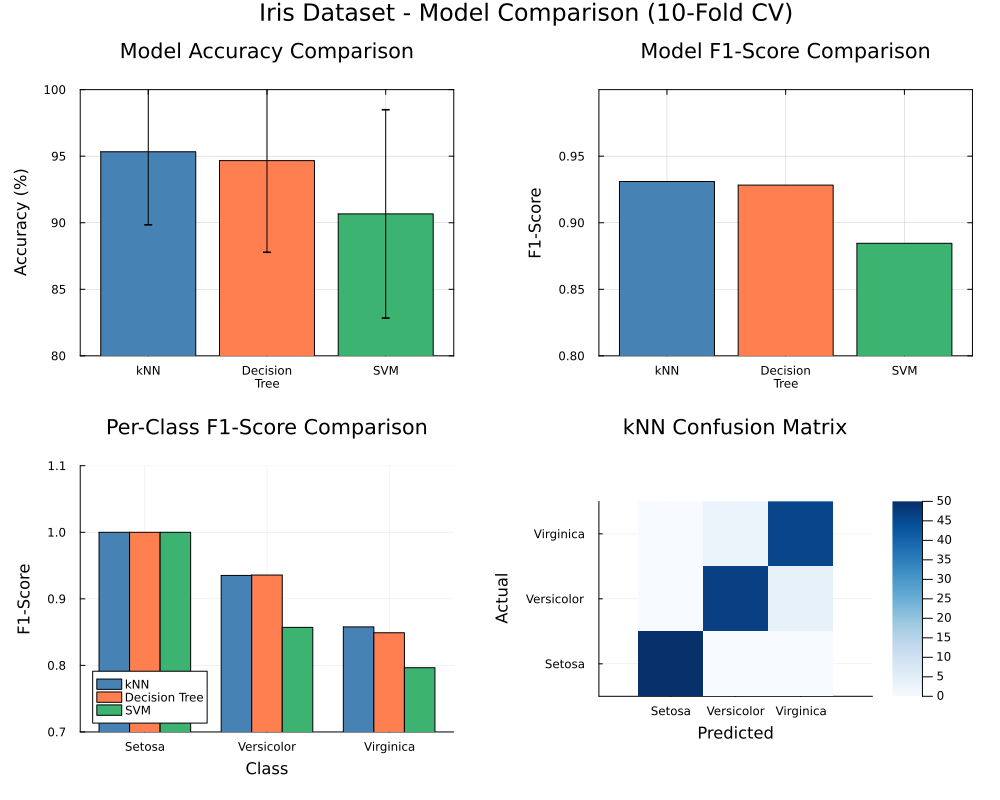

┌ Warning: Indices Base.OneTo(3) of attribute `seriescolor` does not match data indices 2:9.
└ @ Plots ~/.julia/packages/Plots/kLeqV/src/utils.jl:141
┌ Info: Data contains NaNs or missing values, and indices of `seriescolor` vector do not match data indices.
│ If you intend elements of `seriescolor` to apply to individual NaN-separated segments in the data,
│ pass each segment in a separate vector instead, and use a row vector for `seriescolor`. Legend entries
│ may be suppressed by passing an empty label.
│ For example,
└     plot([1:2,1:3], [[4,5],[3,4,5]], label=["y" ""], seriescolor=[1 2])
┌ Warning: Indices Base.OneTo(3) of attribute `fillcolor` does not match data indices 2:9.
└ @ Plots ~/.julia/packages/Plots/kLeqV/src/utils.jl:141
┌ Info: Data contains NaNs or missing values, and indices of `fillcolor` vector do not match data indices.
│ If you intend elements of `fillcolor` to apply to individual NaN-separated segments in the data,
│ pass each segment in a separate vector inst

In [139]:
using Plots

# ============================================
# VISUALIZATION: MODEL COMPARISON
# ============================================

# Prepare data
models_short = ["kNN", "Decision\nTree", "SVM"]
acc_means = [results_knn3[1][1], results_dt4[1][1], results_svm_rbf[1][1]]
acc_stds = [results_knn3[1][2], results_dt4[1][2], results_svm_rbf[1][2]]
f1_means = [mean(results_knn3[7][1]), mean(results_dt4[7][1]), mean(results_svm_rbf[7][1])]

# Create comparison bar plot
p1 = bar(models_short, acc_means * 100,
    yerror = acc_stds * 100,
    ylabel = "Accuracy (%)",
    title = "Model Accuracy Comparison",
    legend = false,
    color = [:steelblue, :coral, :mediumseagreen],
    ylims = (80, 100),
    grid = true,
    framestyle = :box)

p2 = bar(models_short, f1_means,
    ylabel = "F1-Score",
    title = "Model F1-Score Comparison",
    legend = false,
    color = [:steelblue, :coral, :mediumseagreen],
    ylims = (0.8, 1.0),
    grid = true,
    framestyle = :box)

# Per-class performance comparison
class_names = ["Setosa", "Versicolor", "Virginica"]
knn_f1 = results_knn3[7][1]
dt_f1 = results_dt4[7][1]
svm_f1 = results_svm_rbf[7][1]

# Create separate bars for each model (alternative to groupedbar)
x_pos = 1:3
width = 0.25

p3 = bar(x_pos .- width, knn_f1, 
    bar_width = width,
    label = "kNN",
    color = :steelblue,
    ylabel = "F1-Score",
    title = "Per-Class F1-Score Comparison",
    xlabel = "Class",
    xticks = (1:3, class_names),
    ylims = (0.7, 1.1),
    legend = :bottomleft)

bar!(x_pos, dt_f1, 
    bar_width = width,
    label = "Decision Tree",
    color = :coral)

bar!(x_pos .+ width, svm_f1, 
    bar_width = width,
    label = "SVM",
    color = :mediumseagreen)

# Confusion matrices heatmaps
hm1 = heatmap(results_knn3[8], 
    title = "kNN Confusion Matrix",
    xlabel = "Predicted", 
    ylabel = "Actual",
    xticks = (1:3, class_names),
    yticks = (1:3, class_names),
    color = :Blues,
    aspect_ratio = :equal)

# Combined plot
plot(p1, p2, p3, hm1, layout = (2, 2), size = (1000, 800),
    plot_title = "Iris Dataset - Model Comparison (10-Fold CV)",
    margin = 5Plots.mm)

In [143]:
# ============================================
# FINAL MODEL SELECTION AND TRAINING
# ============================================

println("\n" * "="^70)
println("FINAL MODEL TRAINING")
println("="^70)

# Best model is kNN (k=3) with 95.33% accuracy
println("\n Selected Model: kNN (k=3)")
println("   Reason: Highest accuracy (95.33%) and F1-score (0.931)")

# Train final kNN model on ALL data
println("\n Training final model on entire dataset...")

# Create final kNN model
final_model = kNNClassifier(K = 3)

# Train on all normalized data
targets_string = string.(targets)
mach_final = machine(final_model, MLJ.table(inputs_normalized), categorical(targets_string))
MLJ.fit!(mach_final, verbosity=0)

println(" Final model trained successfully!")

# Evaluate on training set (to show perfect fit)
predictions_final = MLJ.predict(mach_final, MLJ.table(inputs_normalized))
outputs_final = string.(mode.(predictions_final))

# Calculate final metrics
classes = unique(targets_string)
final_acc, final_err, final_sens, final_spec, final_ppv, final_npv, final_f1, final_conf = 
    confusionMatrix(outputs_final, targets_string, classes)

println("\n" * "="^70)
println("FINAL MODEL PERFORMANCE (on full dataset)")
println("="^70)
println("  • Accuracy:    $(round(final_acc*100, digits=2))%")
println("  • Error Rate:  $(round(final_err*100, digits=2))%")
println("  • F1-Score:    $(round(mean(final_f1), digits=4))")
println("\n  • Per-class F1-scores:")
for (i, class) in enumerate(classes)
    println("    - $class: $(round(final_f1[i], digits=4))")
end
println("\n  • Final Confusion Matrix:")
println(final_conf)



FINAL MODEL TRAINING

 Selected Model: kNN (k=3)
   Reason: Highest accuracy (95.33%) and F1-score (0.931)

 Training final model on entire dataset...
 Final model trained successfully!

FINAL MODEL PERFORMANCE (on full dataset)
  • Accuracy:    96.67%
  • Error Rate:  3.33%
  • F1-Score:    0.9667

  • Per-class F1-scores:
    - setosa: 1.0
    - versicolor: 0.9505
    - virginica: 0.9495

  • Final Confusion Matrix:
[50 0 0; 0 48 3; 0 2 47]


Three machine learning models were evaluated on the Iris dataset using 10-fold cross-validation: k-Nearest Neighbors (k=3), Decision Tree (max_depth=4), and Support Vector Machine (RBF kernel). 

**kNN (k=3) achieved the best performance** with 95.33% accuracy (±5.49%) and an F1-score of 0.931, followed closely by Decision Tree at 94.67% accuracy and SVM at 90.67% accuracy. 

All models perfectly classified Setosa flowers (100%), but showed some confusion between Versicolor and Virginica classes due to overlapping feature spaces.

The final kNN model trained on the complete dataset achieved **96.67% accuracy**, with only 5 misclassifications out of 150 samples, making it the recommended model for this classification task.

**Best Model:** k-Nearest Neighbors (k=3)  
**Cross-Validation Accuracy:** 95.33% ± 5.49%  
**Final Model Accuracy:** 96.67%  


### Learn Julia

#### Symbols and Dictionaries in Julia
One Julia type that is important for this exercise is the `Symbol` type. An object of this type can be any symbol you want, simply by typing its name after a colon (":"). In this practice, you can use it to indicate which model you want to train, for example, in the `modelCrossValidation` function, symbols will be used to indicate which model to train:

```julia
:KNeighborsClassifier, :SVC, :DecisionTreeClassifier, :ANN
```

#### Passing Model-Specific Parameters
This function will also require model-specific parameters to be passed.
The recommended way to do this is to define a variable of type Dict, which works similarly to Python dictionaries.

For instance, to define the hyperparameters for an artificial neural network (ANN):

```julia
  modelHyperparameters = Dict(
      "topology" => [5, 3],
      "learningRate" => 0.01,
      "validationRatio" => 0.2,
      "numExecutions" => 50,
      "maxEpochs" => 1000,
      "maxEpochsVal" => 6
  )
```

Another way to define the same dictionary:

```julia
  modelHyperparameters = Dict()
  modelHyperparameters["topology"] = topology
  modelHyperparameters["learningRate"] = learningRate
  modelHyperparameters["validationRatio"] = validationRatio
  modelHyperparameters["numExecutions"] = numRepetitionsANNTraining
  modelHyperparameters["maxEpochs"] = numMaxEpochs
  modelHyperparameters["maxEpochsVal"] = maxEpochsVal
```
To access a value, simply use:
```julia
  modelHyperparameters["topology"]
```
#### Example for SVM Parameters
You can also define hyperparameters for other models similarly.
For example, for an SVM:
```julia
  modelHyperparameters = Dict("C" => 1, "kernel" => "rbf", "gamma" => 2)
```
Or using the alternative form:

```julia
  modelHyperparameters = Dict()
  modelHyperparameters["C"] = 1
  modelHyperparameters["kernel"] = "rbf"
  modelHyperparameters["gamma"] = 2
```
Other kernels may require different parameters, such as `degree` and `coef0`.

When building the SVM model inside the function, you might write:
```julia
  if modelHyperparameters["kernel"] == "rbf"
    model = SVMClassifier(
        kernel = LIBSVM.Kernel.RadialBasis,
        cost = Float64(modelHyperparameters["C"]),
        gamma = Float64(modelHyperparameters["gamma"])
    )
```

You can apply a similar strategy for decision trees, kNN, and DoME models.

In the examples above, the dictionary keys are `String`, but you may also use `Symbol` keys interchangeably.
For example:
```julia
  modelHyperparameters = Dict(:C => 1, :kernel => "rbf", :gamma => 2)
```

Another type of Julia that may be interesting for this assignment is the `Symbol` type. An object of this type can be any symbol you want, simply by typing its name after a colon (":"). In this practice, you can use it to indicate which model you want to train, for example `:ANN`, `:SVM`, `:DecisionTree` or `:kNN`.